# A1 Assignment - Harsh Avinash Kammath

## **Renewable Energy Dataset Analysis**

This is a dataset obtained from Kaggle (https://www.kaggle.com/datasets/imtkaggleteam/renewable-energy-1960-2023/data). It focuses on data regarding each countries total amount of renewable energy produced starting from 1960 (in KiloTonne equivalent of Oil). Analysis of this dataset will help us come to conclusions regarding certain regions and mixing with other datasets from World Bank (https://databank.worldbank.org/source/world-development-indicators#) [for GDP] and Our World in Data (https://ourworldindata.org/co2-emissions) [for CO2 emissions] will help us draw conclusions whether the rise in renewable energy production has anything to do with GDP or region or whether using renewable energy has resulted in a reduction of Carbon Dioxide emissions. We will also delve into the world of predictive modelling via Random Forest, Linear Regression Forecast and Prophet forecasting.

This notebook will cover my ideas as I go through the dataset and will have my thoughts as I explore. For a more business report style analysis the report would be an idea place to explore (submitted as part of the assignment).

## ESG & DEIB Considerations

This analysis aligns with the Environmental pillar of ESG by exploring renewable energy trends from 1960 onwards. Sustainable energy is critical for reducing global reliance on fossil fuels, mitigating climate change, and achieving Net Zero targets.Forecasting renewable energy production helps policymakers, investors, and corporations make data-driven decisions on clean energy investments. Understanding trends at a country level allows for targeted policy interventions, funding allocation, and tracking global sustainability goals.

Considerations:
Regional Disparities --> High-income countries (e.g., USA, Germany) might have more complete data, while lower-income nations may have missing or underreported figures.
Data Representation Issues --> Some countries may not have reported historical renewable energy data, leading to potential gaps or misrepresentation in global trends.
Ethical Concerns in Modeling --> Predicting energy trends without considering government policies, subsidies, or socioeconomic factors might introduce unintended biases.

### Library Imports

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

### File Load and Basic Data cleaning and understanding

In [60]:
# Load the dataset
file_path = "/content/renewable_energy.csv"
df = pd.read_csv(file_path)

In [61]:
# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15904 entries, 0 to 15903
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   LOCATION    15904 non-null  object 
 1   INDICATOR   15904 non-null  object 
 2   SUBJECT     15904 non-null  object 
 3   MEASURE     15904 non-null  object 
 4   FREQUENCY   15904 non-null  object 
 5   TIME        15904 non-null  int64  
 6   Value       12017 non-null  float64
 7   Flag Codes  3887 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 994.1+ KB


In [62]:
# Display basic info
df.head()

,LOCATION,INDICATOR,SUBJECT,MEASURE,FREQUENCY,TIME,Value,Flag Codes
0,AUS,RENEWABLE,TOT,KTOE,A,1960,4436.932,NaN
1,AUS,RENEWABLE,TOT,KTOE,A,1961,4490.510,NaN
2,AUS,RENEWABLE,TOT,KTOE,A,1962,4407.097,NaN
3,AUS,RENEWABLE,TOT,KTOE,A,1963,4628.738,NaN
4,AUS,RENEWABLE,TOT,KTOE,A,1964,4497.396,NaN


In [63]:
# Check missing values
print(df.isnull().sum())

LOCATION          0
INDICATOR         0
SUBJECT           0
MEASURE           0
FREQUENCY         0
TIME              0
Value          3887
Flag Codes    12017
dtype: int64


In [64]:
# Drop the 'Flag Codes' column as it's not useful
df.drop(columns=['Flag Codes'], inplace=True)

In [65]:
# Handle missing 'Value' column --> assigning 0 for value as it is energy produced column
df['Value'] = df['Value'].fillna(0)

In [66]:
# Verify changes
print(df.isnull().sum())

LOCATION     0
INDICATOR    0
SUBJECT      0
MEASURE      0
FREQUENCY    0
TIME         0
Value        0
dtype: int64


In [67]:
# Convert time column to integer (if not already)
df['TIME'] = df['TIME'].astype(int)

In [68]:
# Ensure Value column is float
df['Value'] = df['Value'].astype(float)

In [69]:
# Verify changes
df.dtypes

,0
LOCATION,object
INDICATOR,object
SUBJECT,object
MEASURE,object
FREQUENCY,object
TIME,int64
Value,float64


In [70]:
# Check unique measurement units
df['MEASURE'].unique()

array(['KTOE', 'PC_PRYENRGSUPPLY'], dtype=object)

It didn't make sense to have two scales of measurements in the entire dataset. I felt like it was a better way to have a more focused approach on KilloTonnes of Oil equivalent produced as this would provide a accurate approach on well renewable energy has been adopted by countries. (GDP data will be incorporated later)

In [71]:
# Keep only rows where MEASURE is 'KTOE' --> to ensure comparison is with total energy production
df = df[df['MEASURE'] == 'KTOE']

In [72]:
df.to_csv('/content/cleaned_renewable_energy.csv', index=False)

In [73]:
# Load the cleaned dataset
file_path = "/content/cleaned_renewable_energy.csv"
df = pd.read_csv(file_path)

# Check basic info
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7952 entries, 0 to 7951
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LOCATION   7952 non-null   object 
 1   INDICATOR  7952 non-null   object 
 2   SUBJECT    7952 non-null   object 
 3   MEASURE    7952 non-null   object 
 4   FREQUENCY  7952 non-null   object 
 5   TIME       7952 non-null   int64  
 6   Value      7952 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 435.0+ KB


,LOCATION,INDICATOR,SUBJECT,MEASURE,FREQUENCY,TIME,Value
0,AUS,RENEWABLE,TOT,KTOE,A,1960,4436.932
1,AUS,RENEWABLE,TOT,KTOE,A,1961,4490.510
2,AUS,RENEWABLE,TOT,KTOE,A,1962,4407.097
3,AUS,RENEWABLE,TOT,KTOE,A,1963,4628.738
4,AUS,RENEWABLE,TOT,KTOE,A,1964,4497.396


### Initial Graphs

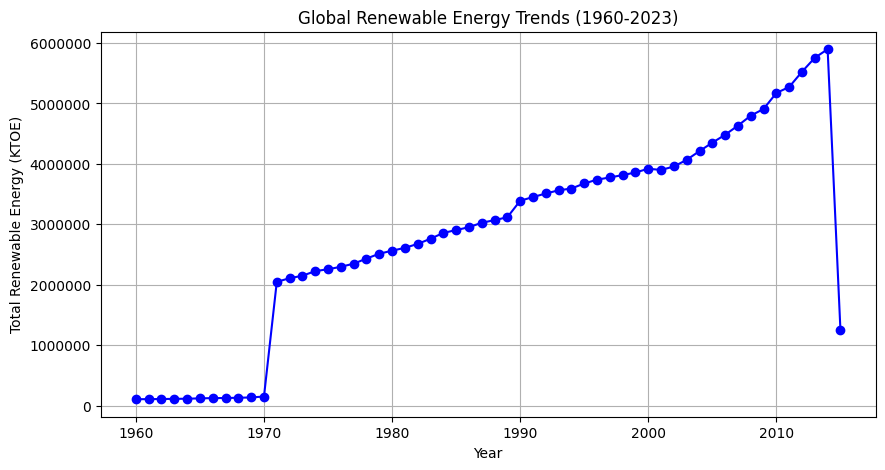

In [74]:
# Aggregate total renewable energy by year
global_trends = df.groupby("TIME")["Value"].sum()

# Plot the trends
plt.figure(figsize=(10,5))
plt.plot(global_trends.index, global_trends.values, marker='o', linestyle='-', color='blue')
plt.xlabel("Year")
plt.ylabel("Total Renewable Energy (KTOE)")
plt.title("Global Renewable Energy Trends (1960-2023)")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()


Such a weird dip in 2015, this is worth exploring. Maybe a data issue or was there a reason for this dip.
The sudden rise in 1970 also is weird. External research shows the 1970s oil crisis as a reason but is this enough to justify a huge rise?

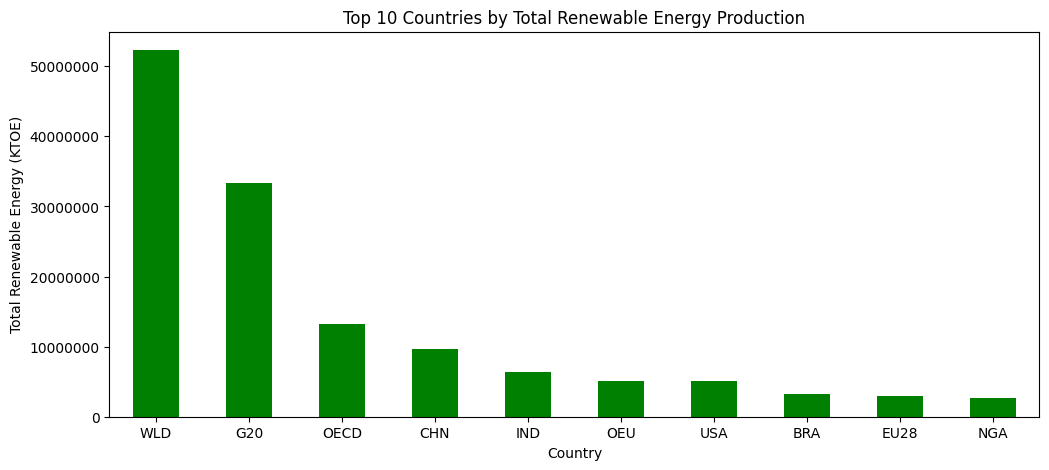

In [75]:
# Aggregate renewable energy production per country
top_countries = df.groupby("LOCATION")["Value"].sum().sort_values(ascending=False).head(10)

# Plot the top 10 countries
plt.figure(figsize=(12,5))
top_countries.plot(kind='bar', color='green')
plt.xlabel("Country")
plt.ylabel("Total Renewable Energy (KTOE)")
plt.title("Top 10 Countries by Total Renewable Energy Production")
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.show()


Such a weird plot as now i realized the data has World, G20, Other European Countries as aggregated data. For our analysis it felt appropriate to remove them.

In [76]:
# Check unique location codes
unique_locations = df["LOCATION"].unique()
print(unique_locations)


['AUS' 'AUT' 'BEL' 'CAN' 'CZE' 'DNK' 'FIN' 'FRA' 'DEU' 'GRC' 'HUN' 'ISL'
 'IRL' 'ITA' 'JPN' 'KOR' 'LUX' 'MEX' 'NLD' 'NZL' 'NOR' 'POL' 'PRT' 'SVK'
 'ESP' 'SWE' 'CHE' 'TUR' 'GBR' 'USA' 'OEU' 'ALB' 'DZA' 'ARG' 'ARM' 'AZE'
 'BGD' 'BLR' 'BIH' 'BRA' 'BRN' 'BGR' 'KHM' 'CHL' 'CHN' 'COL' 'HRV' 'CYP'
 'EGY' 'EST' 'ETH' 'GEO' 'GHA' 'HTI' 'HKG' 'IND' 'IDN' 'IRN' 'ISR' 'KAZ'
 'LVA' 'LTU' 'MKD' 'MYS' 'MLT' 'MDA' 'MOZ' 'NGA' 'PAK' 'PRY' 'PER' 'PHL'
 'ROU' 'RUS' 'SAU' 'SGP' 'SVN' 'ZAF' 'SDN' 'TWN' 'TZA' 'THA' 'UKR' 'ARE'
 'URY' 'VNM' 'ZMB' 'WLD' 'SRB' 'MNE' 'G20' 'EU28' 'OECD' 'AGO' 'BHR' 'BEN'
 'BOL' 'BWA' 'CMR' 'COG' 'CRI' 'CIV' 'CUB' 'PRK' 'COD' 'DOM' 'ECU' 'SLV'
 'ERI' 'GAB' 'GTM' 'HND' 'IRQ' 'JAM' 'JOR' 'KEN' 'KWT' 'KGZ' 'LBN' 'LBY'
 'MNG' 'MAR' 'MMR' 'NAM' 'NPL' 'NIC' 'NER' 'OMN' 'PAN' 'QAT' 'SEN' 'LKA'
 'SYR' 'TJK' 'TGO' 'TTO' 'TUN' 'TKM' 'UZB' 'VEN' 'YEM' 'ZWE']


In [77]:
# List of non-country entries to remove
non_countries = ["WLD", "G20", "OECD", "EU28", "OEU"]

# Remove them from the dataset
df = df[~df["LOCATION"].isin(non_countries)]

# Verify the unique locations again
print("Filtered unique locations:", df["LOCATION"].unique())


Filtered unique locations: ['AUS' 'AUT' 'BEL' 'CAN' 'CZE' 'DNK' 'FIN' 'FRA' 'DEU' 'GRC' 'HUN' 'ISL'
 'IRL' 'ITA' 'JPN' 'KOR' 'LUX' 'MEX' 'NLD' 'NZL' 'NOR' 'POL' 'PRT' 'SVK'
 'ESP' 'SWE' 'CHE' 'TUR' 'GBR' 'USA' 'ALB' 'DZA' 'ARG' 'ARM' 'AZE' 'BGD'
 'BLR' 'BIH' 'BRA' 'BRN' 'BGR' 'KHM' 'CHL' 'CHN' 'COL' 'HRV' 'CYP' 'EGY'
 'EST' 'ETH' 'GEO' 'GHA' 'HTI' 'HKG' 'IND' 'IDN' 'IRN' 'ISR' 'KAZ' 'LVA'
 'LTU' 'MKD' 'MYS' 'MLT' 'MDA' 'MOZ' 'NGA' 'PAK' 'PRY' 'PER' 'PHL' 'ROU'
 'RUS' 'SAU' 'SGP' 'SVN' 'ZAF' 'SDN' 'TWN' 'TZA' 'THA' 'UKR' 'ARE' 'URY'
 'VNM' 'ZMB' 'SRB' 'MNE' 'AGO' 'BHR' 'BEN' 'BOL' 'BWA' 'CMR' 'COG' 'CRI'
 'CIV' 'CUB' 'PRK' 'COD' 'DOM' 'ECU' 'SLV' 'ERI' 'GAB' 'GTM' 'HND' 'IRQ'
 'JAM' 'JOR' 'KEN' 'KWT' 'KGZ' 'LBN' 'LBY' 'MNG' 'MAR' 'MMR' 'NAM' 'NPL'
 'NIC' 'NER' 'OMN' 'PAN' 'QAT' 'SEN' 'LKA' 'SYR' 'TJK' 'TGO' 'TTO' 'TUN'
 'TKM' 'UZB' 'VEN' 'YEM' 'ZWE']


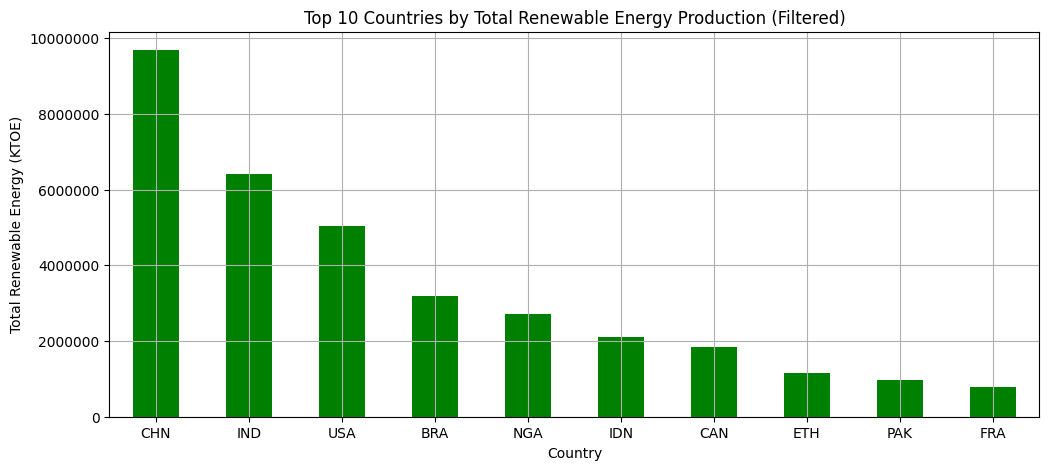

In [78]:
# Aggregate renewable energy production per country
top_countries = df.groupby("LOCATION")["Value"].sum().sort_values(ascending=False).head(10)

# Plot the top 10 countries
plt.figure(figsize=(12,5))
top_countries.plot(kind='bar', color='green')
plt.xlabel("Country")
plt.ylabel("Total Renewable Energy (KTOE)")
plt.title("Top 10 Countries by Total Renewable Energy Production (Filtered)")
plt.xticks(rotation=0)
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()


This graph looks much better and we can come up with conclusions for our report.

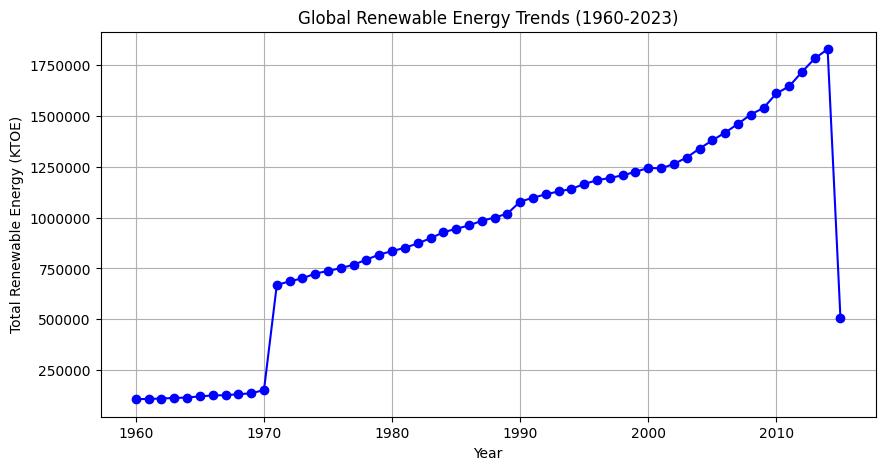

In [79]:
# Aggregate total renewable energy by year
global_trends = df.groupby("TIME")["Value"].sum()

# Plot the trends
plt.figure(figsize=(10,5))
plt.plot(global_trends.index, global_trends.values, marker='o', linestyle='-', color='blue')
plt.xlabel("Year")
plt.ylabel("Total Renewable Energy (KTOE)")
plt.title("Global Renewable Energy Trends (1960-2023)")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()


However, this data still looks so bad. Lets explore further now by checking the countries which have no data in 2015 but have data in 2014 (its highly unlikely that a country producing renewable energy go to 0 produced in 2015)

In [80]:
# Get energy production per country for 2014 and 2015
energy_2014 = df[df["TIME"] == 2014].groupby("LOCATION")["Value"].sum()
energy_2015 = df[df["TIME"] == 2015].groupby("LOCATION")["Value"].sum()

# Merge both into a comparison DataFrame
comparison_df = pd.DataFrame({"Energy_2014": energy_2014, "Energy_2015": energy_2015})

# Fill NaN (countries missing in 2015) with 0 for comparison
comparison_df.fillna(0, inplace=True)

# Filter countries where 2015 energy is 0 but 2014 had a nonzero value
zero_2015_countries = comparison_df[(comparison_df["Energy_2014"] > 0) & (comparison_df["Energy_2015"] == 0)]

zero_2015_countries


,Energy_2014,Energy_2015
LOCATION,,
AGO,7588.810,0.0
ALB,637.313,0.0
ARE,124.939,0.0
ARG,7576.154,0.0
ARM,205.542,0.0
...,...,...
VNM,20379.268,0.0
YEM,113.860,0.0
ZAF,15880.488,0.0


Ok this confirms a missing data case. Rather than correcting the data for **99** countries, its better to avoid data from this year.

In [81]:
# Keep only data up to 2014
df = df[df["TIME"] <= 2014]

# Save the cleaned dataset
df.to_csv("/content/cleaned_renewable_energy_final.csv", index=False)

# Verify final dataset
df["TIME"].max()  # Should return 2014


2014

In [82]:
# Load the final cleaned dataset
file_path = "/content/cleaned_renewable_energy_final.csv"
df = pd.read_csv(file_path)

# Check basic info
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LOCATION   7535 non-null   object 
 1   INDICATOR  7535 non-null   object 
 2   SUBJECT    7535 non-null   object 
 3   MEASURE    7535 non-null   object 
 4   FREQUENCY  7535 non-null   object 
 5   TIME       7535 non-null   int64  
 6   Value      7535 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 412.2+ KB


,LOCATION,INDICATOR,SUBJECT,MEASURE,FREQUENCY,TIME,Value
0,AUS,RENEWABLE,TOT,KTOE,A,1960,4436.932
1,AUS,RENEWABLE,TOT,KTOE,A,1961,4490.510
2,AUS,RENEWABLE,TOT,KTOE,A,1962,4407.097
3,AUS,RENEWABLE,TOT,KTOE,A,1963,4628.738
4,AUS,RENEWABLE,TOT,KTOE,A,1964,4497.396


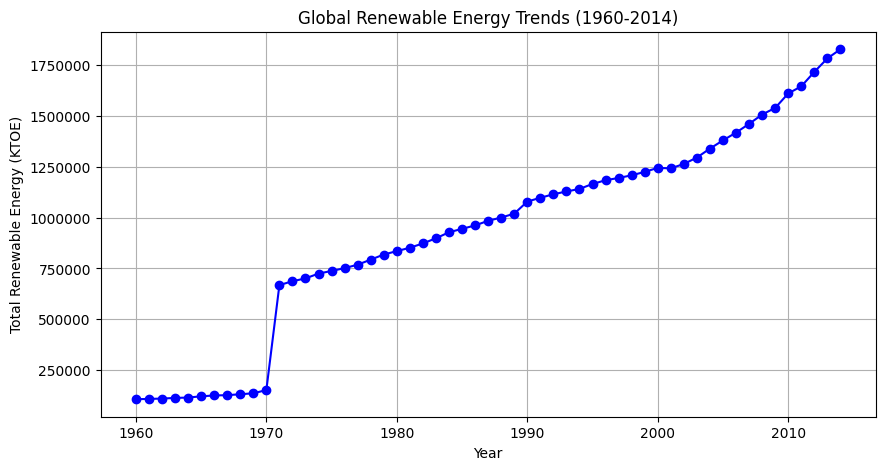

In [83]:
# Aggregate total renewable energy by year
global_trends = df.groupby("TIME")["Value"].sum()

# Plot the trends
plt.figure(figsize=(10,5))
plt.plot(global_trends.index, global_trends.values, marker='o', linestyle='-', color='blue')
plt.xlabel("Year")
plt.ylabel("Total Renewable Energy (KTOE)")
plt.title("Global Renewable Energy Trends (1960-2014)")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()


Much better without the random dip in 2015.Lets see whats up with 1970.

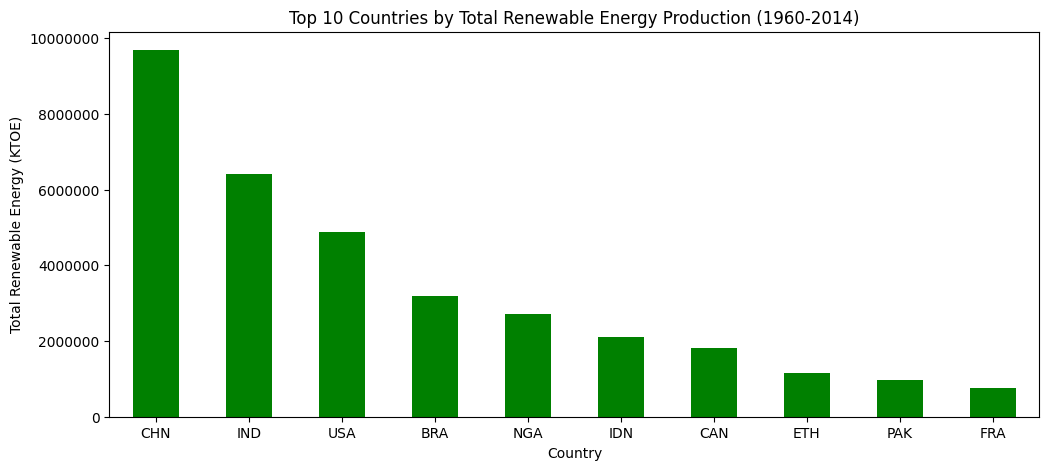

In [84]:
# Aggregate renewable energy production per country
top_countries = df.groupby("LOCATION")["Value"].sum().sort_values(ascending=False).head(10)

# Plot the top 10 countries
plt.figure(figsize=(12,5))
top_countries.plot(kind='bar', color='green')
plt.xlabel("Country")
plt.ylabel("Total Renewable Energy (KTOE)")
plt.title("Top 10 Countries by Total Renewable Energy Production (1960-2014)")
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=0)
plt.show()


Corrected plot for all countries.

<Figure size 1200x600 with 0 Axes>

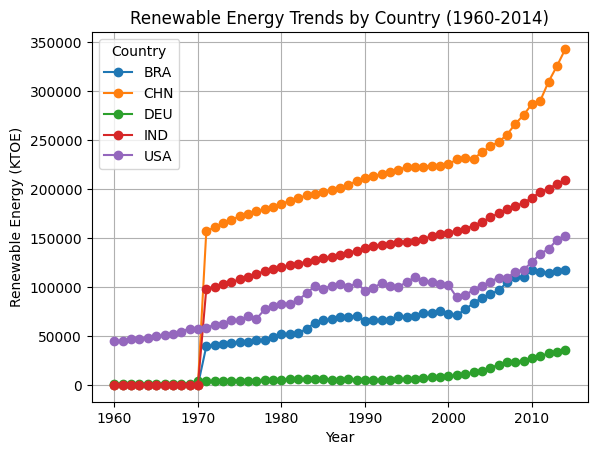

In [85]:
# Select a few major countries for comparison
selected_countries = ['USA', 'CHN', 'IND', 'DEU', 'BRA']  # Add more if needed

# Filter and group data
df_selected = df[df['LOCATION'].isin(selected_countries)]
regional_trends = df_selected.groupby(["TIME", "LOCATION"])["Value"].sum().unstack()

# Plot trends
plt.figure(figsize=(12,6))
regional_trends.plot(marker='o')
plt.xlabel("Year")
plt.ylabel("Renewable Energy (KTOE)")
plt.title("Renewable Energy Trends by Country (1960-2014)")
plt.legend(title="Country")
plt.grid(True)
plt.show()


Exploring trends and seeing the impact of 1970 oil crisis and effects of other important conventions over the years.

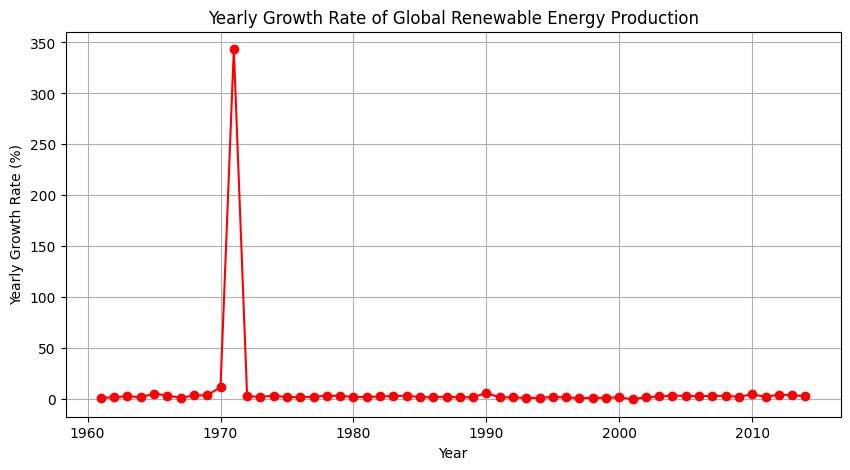

In [86]:
# Compute percentage change (growth rate)
df_growth = global_trends.pct_change() * 100

# Plot growth rate trends
plt.figure(figsize=(10,5))
plt.plot(df_growth.index, df_growth.values, marker='o', linestyle='-', color='red')
plt.xlabel("Year")
plt.ylabel("Yearly Growth Rate (%)")
plt.title("Yearly Growth Rate of Global Renewable Energy Production")
plt.grid(True)
plt.show()

1970 data is skewed so heavily :?

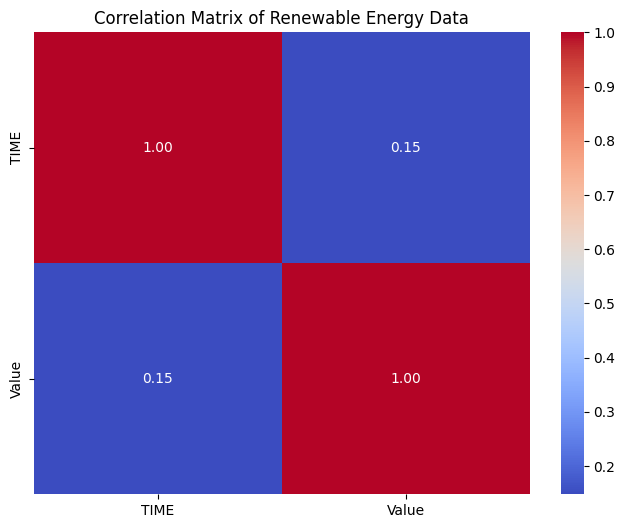

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
df_numeric = df.select_dtypes(include=["number"])

# Compute correlation matrix
correlation_matrix = df_numeric.corr()

# Display as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Renewable Energy Data")
plt.show()


We have very few external sources/factors involved currently. Lets address that first.

### External Datasets Merge and Data Exploration

In [88]:
# Load datasets
gdp_file = "/content/Data_GDP_Current_USD.csv"  # Update path if needed
co2_file = "/content/annual-co2-emissions-per-country.csv"
renewable_file = "/content/cleaned_renewable_energy_final.csv"

df_gdp = pd.read_csv(gdp_file)
df_co2 = pd.read_csv(co2_file)
df_renewable = pd.read_csv(renewable_file)

# Display first few rows
df_gdp.head(), df_co2.head(), df_renewable.head()


(     Country Name Country Code        Series Name     Series Code  \
 0     Afghanistan          AFG  GDP (current US$)  NY.GDP.MKTP.CD   
 1         Albania          ALB  GDP (current US$)  NY.GDP.MKTP.CD   
 2         Algeria          DZA  GDP (current US$)  NY.GDP.MKTP.CD   
 3  American Samoa          ASM  GDP (current US$)  NY.GDP.MKTP.CD   
 4         Andorra          AND  GDP (current US$)  NY.GDP.MKTP.CD   
 
       1960 [YR1960]     1961 [YR1961]     1962 [YR1962]     1963 [YR1963]  \
 0                ..                ..                ..                ..   
 1                ..                ..                ..                ..   
 2  2723615451.30098  2434747055.94018  2001444543.91885  2702982017.63803   
 3                ..                ..                ..                ..   
 4                ..                ..                ..                ..   
 
      1964 [YR1964]     1965 [YR1965]  ...     2014 [YR2014]     2015 [YR2015]  \
 0               ..       

In [89]:
# Drop unnecessary columns
df_gdp = df_gdp.drop(columns=["Country Name", "Series Name", "Series Code"])

# Convert from wide to long format
df_gdp = df_gdp.melt(id_vars=["Country Code"], var_name="Year", value_name="GDP")

# Clean up the 'Year' column (remove [YRxxxx] text)
df_gdp["Year"] = df_gdp["Year"].str.extract(r'(\d{4})').astype(int)

# Convert GDP values to numeric (handle missing values)
df_gdp["GDP"] = pd.to_numeric(df_gdp["GDP"], errors="coerce")

# Drop rows with missing GDP values
df_gdp = df_gdp.dropna()

# Verify cleaning
df_gdp.head()


,Country Code,Year,GDP
2,DZA,1960,2.723615e+09
10,AUS,1960,1.860768e+10
11,AUT,1960,6.624086e+09
13,BHS,1960,1.697360e+08
15,BGD,1960,4.274894e+09


In [90]:
# Keep only relevant columns
df_co2 = df_co2[["Code", "Year", "Annual CO₂ emissions"]]

# Rename columns for consistency
df_co2 = df_co2.rename(columns={"Code": "Country Code", "Annual CO₂ emissions": "CO2_Emissions"})

# Drop rows where 'Country Code' is missing
df_co2 = df_co2.dropna(subset=["Country Code"])

# Verify cleaning
df_co2.head()


,Country Code,Year,CO2_Emissions
0,AFG,1949,14656.0
1,AFG,1950,84272.0
2,AFG,1951,91600.0
3,AFG,1952,91600.0
4,AFG,1953,106256.0


In [91]:
print("Renewable Energy Data Columns:", df_renewable.columns)
print("GDP Data Columns:", df_gdp.columns)
print("CO2 Data Columns:", df_co2.columns)


Renewable Energy Data Columns: Index(['LOCATION', 'INDICATOR', 'SUBJECT', 'MEASURE', 'FREQUENCY', 'TIME',
       'Value'],
      dtype='object')
GDP Data Columns: Index(['Country Code', 'Year', 'GDP'], dtype='object')
CO2 Data Columns: Index(['Country Code', 'Year', 'CO2_Emissions'], dtype='object')


In [92]:
# Standardize column names
df_renewable.rename(columns={"LOCATION": "COUNTRY_CODE", "TIME": "Year"}, inplace=True)
df_gdp.rename(columns={"Country Code": "COUNTRY_CODE"}, inplace=True)
df_co2.rename(columns={"Country Code": "COUNTRY_CODE"}, inplace=True)


In [93]:
# Ensure 'Year' is an integer
df_renewable["Year"] = df_renewable["Year"].astype(int)
df_gdp["Year"] = df_gdp["Year"].astype(int)
df_co2["Year"] = df_co2["Year"].astype(int)

# Ensure 'COUNTRY_CODE' is a string (important for merging)
df_renewable["COUNTRY_CODE"] = df_renewable["COUNTRY_CODE"].astype(str)
df_gdp["COUNTRY_CODE"] = df_gdp["COUNTRY_CODE"].astype(str)
df_co2["COUNTRY_CODE"] = df_co2["COUNTRY_CODE"].astype(str)


In [94]:
# Merge Renewable Energy with GDP
df_merged = df_renewable.merge(df_gdp, on=["COUNTRY_CODE", "Year"], how="left")

# Merge with CO2 Emissions
df_merged = df_merged.merge(df_co2, on=["COUNTRY_CODE", "Year"], how="left")

# Save the final merged dataset
df_merged.to_csv("/content/Final_Merged_Dataset.csv", index=False)

# Verify the final dataset
df_merged.head()


,COUNTRY_CODE,INDICATOR,SUBJECT,MEASURE,FREQUENCY,Year,Value,GDP,CO2_Emissions
0,AUS,RENEWABLE,TOT,KTOE,A,1960,4436.932,1.860768e+10,87444264.0
1,AUS,RENEWABLE,TOT,KTOE,A,1961,4490.510,1.968400e+10,87009520.0
2,AUS,RENEWABLE,TOT,KTOE,A,1962,4407.097,1.992368e+10,90908610.0
3,AUS,RENEWABLE,TOT,KTOE,A,1963,4628.738,2.154096e+10,95995810.0
4,AUS,RENEWABLE,TOT,KTOE,A,1964,4497.396,2.380112e+10,103544750.0


In [95]:
#Exploring dataset with basic stats
df_merged.describe()

,Year,Value,GDP,CO2_Emissions
count,7535.000000,7535.000000,6.303000e+03,7.454000e+03
mean,1987.000000,6783.319142,2.100304e+11,1.542369e+08
std,15.875561,23521.721212,9.241363e+11,5.889044e+08
min,1960.000000,0.000000,3.041141e+07,1.099200e+04
25%,1973.000000,0.000000,4.683749e+09,4.786388e+06
50%,1987.000000,818.244000,1.727176e+10,2.072775e+07
75%,2001.000000,4469.606500,8.728095e+10,7.673169e+07
max,2014.000000,342880.843000,1.760814e+13,9.990257e+09


In [96]:
# Checking value counts
df_merged.value_counts()

COUNTRY_CODE  INDICATOR  SUBJECT  MEASURE  FREQUENCY  Year  Value      GDP           CO2_Emissions
AGO           RENEWABLE  TOT      KTOE     A          1980  3652.131   5.930503e+09  5334352.0        1
NGA           RENEWABLE  TOT      KTOE     A          1985  45476.182  7.374582e+10  69635960.0       1
                                                      1983  42902.499  9.709491e+10  59705244.0       1
                                                      1982  41767.651  1.427694e+11  65393570.0       1
                                                      1981  40600.709  1.644752e+11  65810500.0       1
                                                                                                     ..
GAB           RENEWABLE  TOT      KTOE     A          1973  508.190    7.227807e+08  5309136.0        1
                                                      1972  497.086    4.305084e+08  2737008.0        1
                                                      1971  486.388    3.816871e+08  2843264.0        1
                                                      1970  0.000      3.238025e+08  2081152.0        1
ZWE           RENEWABLE  TOT      KTOE     A          2014  7788.928   1.949552e+10  11946148.0       1
Name: count, Length: 6274, dtype: int64

Correlation Matrix now to see how related the new data is!!

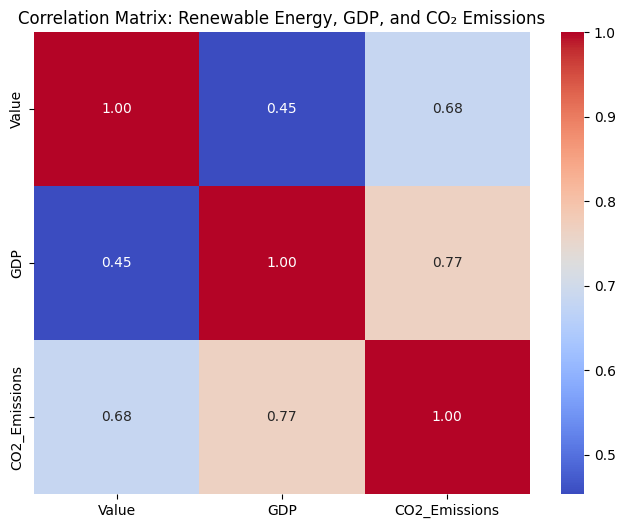

In [97]:
# Select only numeric columns for correlation
df_corr = df_merged[["Value", "GDP", "CO2_Emissions"]].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Renewable Energy, GDP, and CO₂ Emissions")
plt.show()


Time now to see which country was skewing our dataset (it was Denmark ⏰)

In [98]:
df_denmark = df_merged[df_merged["COUNTRY_CODE"] == "DNK"]
df_denmark


,COUNTRY_CODE,INDICATOR,SUBJECT,MEASURE,FREQUENCY,Year,Value,GDP,CO2_Emissions
275,DNK,RENEWABLE,TOT,KTOE,A,1960,2.150,6.361167e+09,29749520.0
276,DNK,RENEWABLE,TOT,KTOE,A,1961,2.236,7.058361e+09,31701866.0
277,DNK,RENEWABLE,TOT,KTOE,A,1962,2.236,7.953275e+09,36889884.0
278,DNK,RENEWABLE,TOT,KTOE,A,1963,2.150,8.466045e+09,40667910.0
279,DNK,RENEWABLE,TOT,KTOE,A,1964,2.150,9.677401e+09,43146930.0
280,DNK,RENEWABLE,TOT,KTOE,A,1965,2.150,1.087067e+10,44293370.0
281,DNK,RENEWABLE,TOT,KTOE,A,1966,2.236,1.193174e+10,50078412.0
282,DNK,RENEWABLE,TOT,KTOE,A,1967,2.150,1.305906e+10,49026428.0
283,DNK,RENEWABLE,TOT,KTOE,A,1968,1.806,1.350557e+10,53272676.0
284,DNK,RENEWABLE,TOT,KTOE,A,1969,1.892,1.541490e+10,59342588.0


This sudden rise in 1970 is not backed by any data sources. Only explanation is that the data collection for Denmark was done wrongly or misrepresented in this dataset.

In [99]:
# Create a proper copy to avoid SettingWithCopyWarning
df_no_denmark = df_merged[df_merged["COUNTRY_CODE"] != "DNK"].copy()

# Compute percentage change for each country
df_no_denmark["GDP_Perc_Change"] = df_no_denmark.groupby("COUNTRY_CODE")["GDP"].pct_change() * 100
df_no_denmark["Renewable_Perc_Change"] = df_no_denmark.groupby("COUNTRY_CODE")["Value"].pct_change() * 100
df_no_denmark["CO2_Perc_Change"] = df_no_denmark.groupby("COUNTRY_CODE")["CO2_Emissions"].pct_change() * 100

# Fill any NaN values that may arise due to first-year calculations
df_no_denmark.fillna(0, inplace=True)

# Verify changes
df_no_denmark.head()


<ipython-input-99-7a35ce6acc0b>:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_no_denmark["GDP_Perc_Change"] = df_no_denmark.groupby("COUNTRY_CODE")["GDP"].pct_change() * 100
<ipython-input-99-7a35ce6acc0b>:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_no_denmark["CO2_Perc_Change"] = df_no_denmark.groupby("COUNTRY_CODE")["CO2_Emissions"].pct_change() * 100


,COUNTRY_CODE,INDICATOR,SUBJECT,MEASURE,FREQUENCY,Year,Value,GDP,CO2_Emissions,GDP_Perc_Change,Renewable_Perc_Change,CO2_Perc_Change
0,AUS,RENEWABLE,TOT,KTOE,A,1960,4436.932,1.860768e+10,87444264.0,0.000000,0.000000,0.000000
1,AUS,RENEWABLE,TOT,KTOE,A,1961,4490.510,1.968400e+10,87009520.0,5.784278,1.207546,-0.497167
2,AUS,RENEWABLE,TOT,KTOE,A,1962,4407.097,1.992368e+10,90908610.0,1.217639,-1.857540,4.481222
3,AUS,RENEWABLE,TOT,KTOE,A,1963,4628.738,2.154096e+10,95995810.0,8.117376,5.029184,5.595950
4,AUS,RENEWABLE,TOT,KTOE,A,1964,4497.396,2.380112e+10,103544750.0,10.492383,-2.837534,7.863822


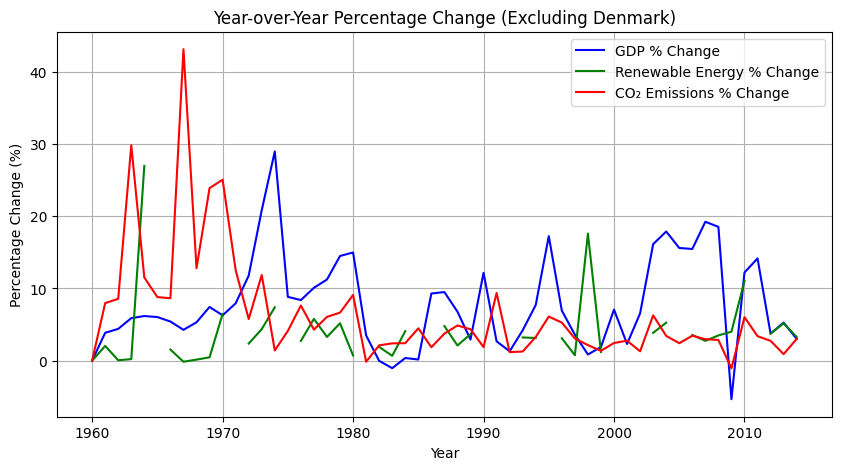

In [100]:
# Aggregate global trends by year (without Denmark)
df_perc_change_no_denmark = df_no_denmark.groupby("Year")[["GDP_Perc_Change", "Renewable_Perc_Change", "CO2_Perc_Change"]].mean()

# Plot percentage change trends (without Denmark)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_perc_change_no_denmark.index, df_perc_change_no_denmark["GDP_Perc_Change"], label="GDP % Change", color="blue")
plt.plot(df_perc_change_no_denmark.index, df_perc_change_no_denmark["Renewable_Perc_Change"], label="Renewable Energy % Change", color="green")
plt.plot(df_perc_change_no_denmark.index, df_perc_change_no_denmark["CO2_Perc_Change"], label="CO₂ Emissions % Change", color="red")
plt.xlabel("Year")
plt.ylabel("Percentage Change (%)")
plt.title("Year-over-Year Percentage Change (Excluding Denmark)")
plt.legend()
plt.grid(True)
plt.show()


This Percentage change graph is a much better representation

### Hypothesis Tests

#### Relationship between GDP and Renewable Energy Production

In [101]:
import scipy.stats as stats

# Filter for most recent year available
latest_year = df_no_denmark["Year"].max()
df_latest = df_no_denmark[df_no_denmark["Year"] == latest_year]

# Perform Pearson correlation test
corr, p_value = stats.pearsonr(df_latest["GDP"], df_latest["Value"])

print(f"Correlation: {corr:.2f}, P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Reject H₀: There is a significant relationship between GDP and renewable energy.")
else:
    print("Fail to reject H₀: No significant relationship found.")


Correlation: 0.69, P-value: 0.0000
Reject H₀: There is a significant relationship between GDP and renewable energy.


#### rRelationship between CO2 Emissions and Renewable Energy production

In [102]:
# Perform Pearson correlation test
corr, p_value = stats.pearsonr(df_latest["Value"], df_latest["CO2_Emissions"])

print(f"Correlation: {corr:.2f}, P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Reject H₀: More renewables significantly reduce CO₂ emissions.")
else:
    print("Fail to reject H₀: No clear relationship found.")


Correlation: 0.86, P-value: 0.0000
Reject H₀: More renewables significantly reduce CO₂ emissions.


I think its time to explore something region specific now.

In [103]:
!pip install pycountry-convert


Mapping countries to continents

In [104]:
import pycountry_convert as pc
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Function to map country codes to continents
def country_to_continent(country_code):
    try:
        continent_code = pc.country_alpha2_to_continent_code(pc.country_alpha3_to_country_alpha2(country_code))
        continent_map = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania",
        }
        return continent_map.get(continent_code, "Unknown")
    except:
        return "Unknown"

# Apply mapping function
df_no_denmark["Continent"] = df_no_denmark["COUNTRY_CODE"].apply(country_to_continent)

# Verify mapping
print(df_no_denmark["Continent"].value_counts())


Continent
Asia             2420
Europe           2090
Africa           1540
North America     770
South America     550
Oceania           110
Name: count, dtype: int64


In [105]:
# Aggregate renewable energy and CO2 emissions by continent
df_continent = df_no_denmark.groupby("Continent")[["GDP", "Value"]].sum().reset_index()

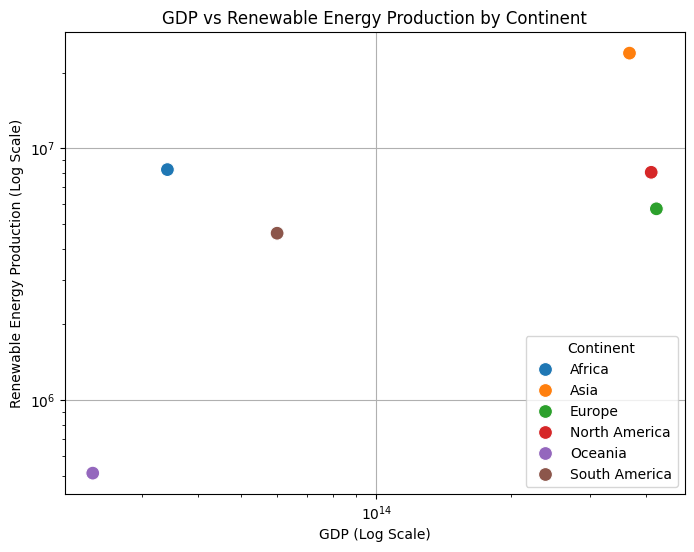

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_continent, x="GDP", y="Value", hue="Continent", palette="tab10", s=100)
plt.xscale("log")  # Log scale for better visualization
plt.yscale("log")
plt.xlabel("GDP (Log Scale)")
plt.ylabel("Renewable Energy Production (Log Scale)")
plt.title("GDP vs Renewable Energy Production by Continent")
plt.legend(title="Continent")
plt.grid(True)
plt.show()


Interesting trends to be explored for the report

In [107]:
# Aggregate renewable energy and CO2 emissions by continent
df_continent = df_no_denmark.groupby("Continent")[["Value", "CO2_Emissions"]].sum().reset_index()


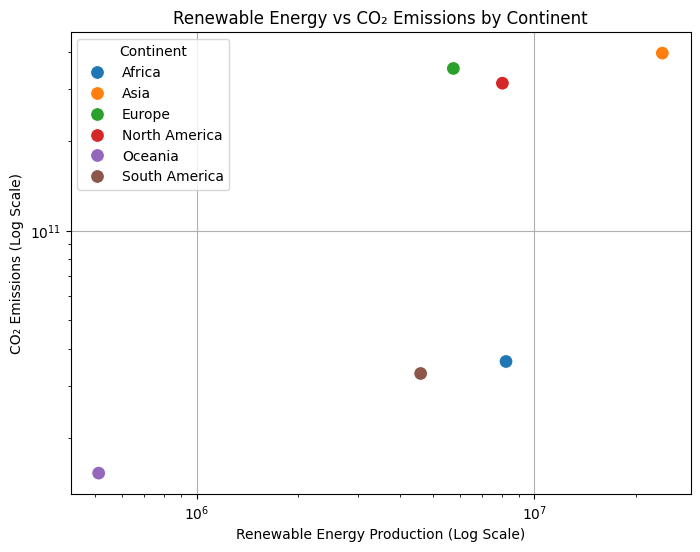

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot Renewable Energy vs. CO₂ Emissions by Continent
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_continent, x="Value", y="CO2_Emissions", hue="Continent", palette="tab10", s=100)
plt.xscale("log")  # Log scale for better visualization
plt.yscale("log")
plt.xlabel("Renewable Energy Production (Log Scale)")
plt.ylabel("CO₂ Emissions (Log Scale)")
plt.title("Renewable Energy vs CO₂ Emissions by Continent")
plt.legend(title="Continent")
plt.grid(True)
plt.show()


Similar points here

### Predictive Modelling

#### Random Forest Generator

Focusing on data from 1990 onwards to see if the our model can perform well

RMSE: 8147.88


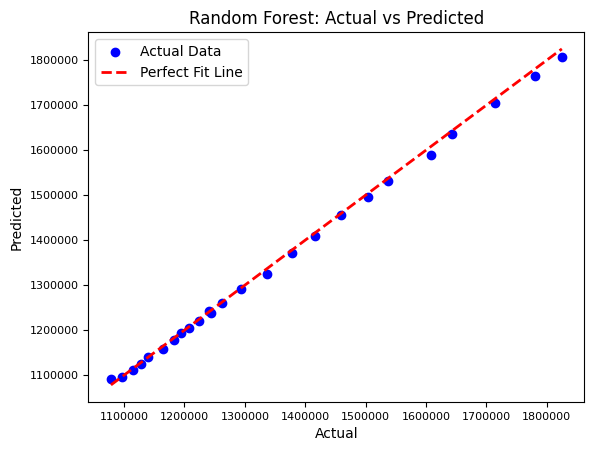

In [122]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Prepare the dataset for Random Forest
df_no_denmark = df_no_denmark[df_no_denmark['Year'] >= 1990]  # Use data from 1990 onwards
df_aggregated = df_no_denmark.groupby('Year')['Value'].sum().reset_index()  # Aggregate data by year

# Prepare the features (X) and target (y)
X = df_aggregated[['Year']]  # Feature - Year
y = df_aggregated['Value']  # Target - Renewable energy production

# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Make predictions for the entire dataset
y_pred = rf_model.predict(X)

# Calculate RMSE
mse = mean_squared_error(y, y_pred)
rmse = mse ** 0.5
print(f"RMSE: {rmse:.2f}")

# Plot the actual vs predicted values
plt.scatter(y, y_pred, color='blue', label='Actual Data')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect Fit Line')
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.legend()
plt.show()


#### Holt-Winters Model
ARIMA forecast was heavily influenced by peaks, using Holt-Winters Model was a better predictor, however I began to explore better models for my report.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Test RMSE: 9844.00


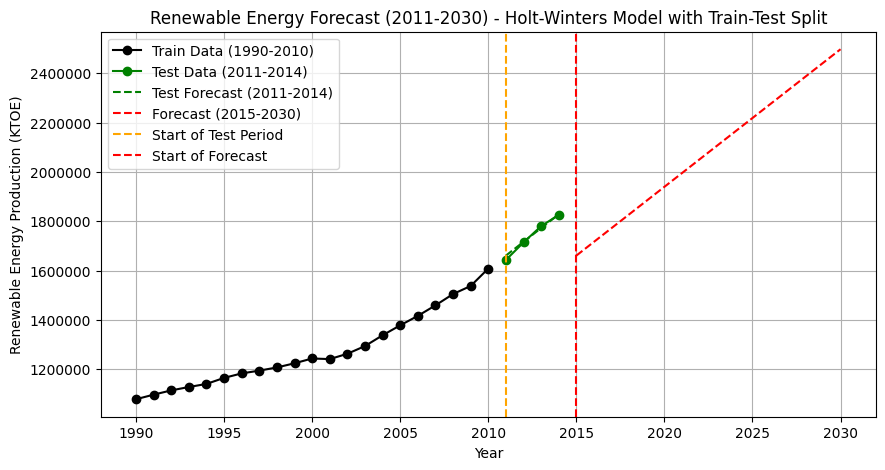

In [110]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# ✅ Aggregate data by year
df_timeseries = df_no_denmark.groupby("Year")["Value"].sum().reset_index()

# ✅ Train-Test Split: (Train: 1990-2010, Test: 2011-2014)
train = df_timeseries[df_timeseries["Year"] < 2011]
test = df_timeseries[(df_timeseries["Year"] >= 2011) & (df_timeseries["Year"] < 2015)]

# ✅ Fit the Holt-Winters Model using only the train data
model = ExponentialSmoothing(train["Value"], trend="add", seasonal=None)
model_fit = model.fit()

# ✅ Forecast for Test Period (2011-2014)
test_forecast = model_fit.forecast(steps=len(test))

# ✅ Evaluate Model Performance on Test Data
rmse = np.sqrt(mean_squared_error(test["Value"], test_forecast))
print(f"Test RMSE: {rmse:.2f}")

# ✅ Forecast for Long-Term (2015-2030)
future_years = list(range(2015, 2031))
future_forecast = model_fit.forecast(steps=len(future_years))

# ✅ Plot Results with Train-Test Split
plt.figure(figsize=(10, 5))

# Plot actual values
plt.plot(train["Year"], train["Value"], label="Train Data (1990-2010)", color="black", marker='o')
plt.plot(test["Year"], test["Value"], label="Test Data (2011-2014)", color="green", marker='o')

# Plot forecasts
plt.plot(test["Year"], test_forecast, label="Test Forecast (2011-2014)", linestyle="dashed", color="green")
plt.plot(future_years, future_forecast, label="Forecast (2015-2030)", linestyle="dashed", color="red")

# Mark split points
plt.axvline(x=2011, color='orange', linestyle="dashed", label="Start of Test Period")
plt.axvline(x=2015, color='red', linestyle="dashed", label="Start of Forecast")

# Labels and title
plt.xlabel("Year")
plt.ylabel("Renewable Energy Production (KTOE)")
plt.title("Renewable Energy Forecast (2011-2030) - Holt-Winters Model with Train-Test Split")
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
# Show the plot
plt.show()


#### Prophet Model

Prophet modelling is something I explored during my A2 assignment and it felt appropriate to use here as we can see results with a model which gives upper and lower bounds to its predictions as well.

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpbalc617k/xccp8otp.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpbalc617k/6hkrwtfr.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=49910', 'data', 'file=/tmp/tmpbalc617k/xccp8otp.json', 'init=/tmp/tmpbalc617k/6hkrwtfr.json', 'output', 'file=/tmp/tmpbalc617k/prophet_model63g93jko/prophet_model-20250301235414.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:54:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:54:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:

Test RMSE: 42363.70


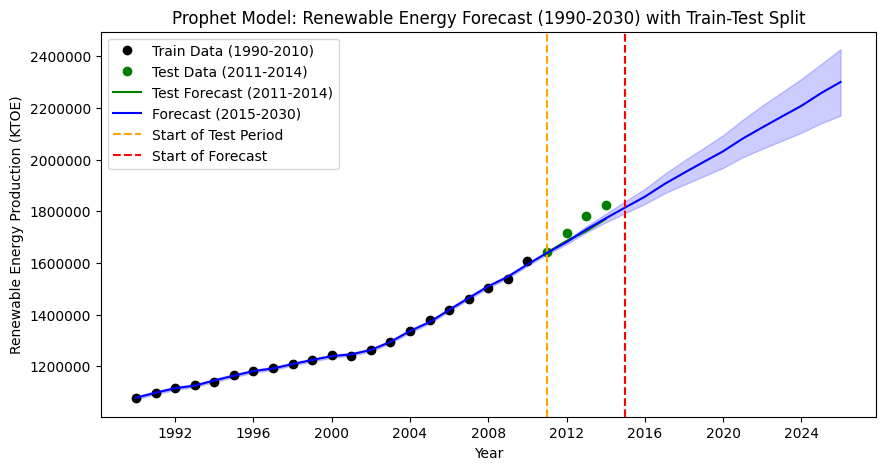

In [111]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# ✅ Load Data (Replace df_no_denmark with your actual dataset)
df = df_no_denmark.copy()

# ✅ Keep only relevant columns and rename for Prophet
df_filtered = df[["Year", "Value"]].rename(columns={"Year": "ds", "Value": "y"})

# ✅ Ensure ds column is in datetime format
df_filtered["ds"] = pd.to_datetime(df_filtered["ds"], format="%Y")

# ✅ Filter data from **1990 onwards only**
df_filtered = df_filtered[df_filtered["ds"] >= "1990"]

# ✅ Drop duplicates and aggregate data (if needed)
df_filtered = df_filtered.groupby("ds").agg({"y": "sum"}).reset_index()

# ✅ Split Data: Train-Test Split (Train: 1990-2010, Test: 2011-2014)
train = df_filtered[df_filtered["ds"] < "2011"]
test = df_filtered[(df_filtered["ds"] >= "2011") & (df_filtered["ds"] < "2015")]

# ✅ Initialize and Train Prophet Model
model = Prophet(yearly_seasonality=True)
model.fit(train)

# ✅ Create Future Dates for Test Period (2011-2014)
test_future = test[["ds"]]
test_forecast = model.predict(test_future)

# ✅ Evaluate Model Performance on Test Data
rmse = np.sqrt(mean_squared_error(test["y"], test_forecast["yhat"]))
print(f"Test RMSE: {rmse:.2f}")

# ✅ Create Future Dates for Long-Term Forecast (2015-2030)
future = model.make_future_dataframe(periods=16, freq="YE")  # 16 years ahead
forecast = model.predict(future)

# ✅ Plot Forecast with Actual Data
plt.figure(figsize=(10, 5))
plt.plot(train["ds"], train["y"], 'ko', label="Train Data (1990-2010)")  # Black dots for train data
plt.plot(test["ds"], test["y"], 'go', label="Test Data (2011-2014)")  # Green dots for test data
plt.plot(test_forecast["ds"], test_forecast["yhat"], 'g-', label="Test Forecast (2011-2014)")  # Test forecast
plt.plot(forecast["ds"], forecast["yhat"], 'b-', label="Forecast (2015-2030)")  # Forecast in blue
plt.axvline(x=pd.to_datetime("2011-01-01"), color='orange', linestyle="dashed", label="Start of Test Period")
plt.axvline(x=pd.to_datetime("2015-01-01"), color='red', linestyle="dashed", label="Start of Forecast")
plt.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], color="blue", alpha=0.2)
plt.xlabel("Year")
plt.ylabel("Renewable Energy Production (KTOE)")
plt.title("Prophet Model: Renewable Energy Forecast (1990-2030) with Train-Test Split")
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.show()


#### Linear Regression

RMSE: 74350.44


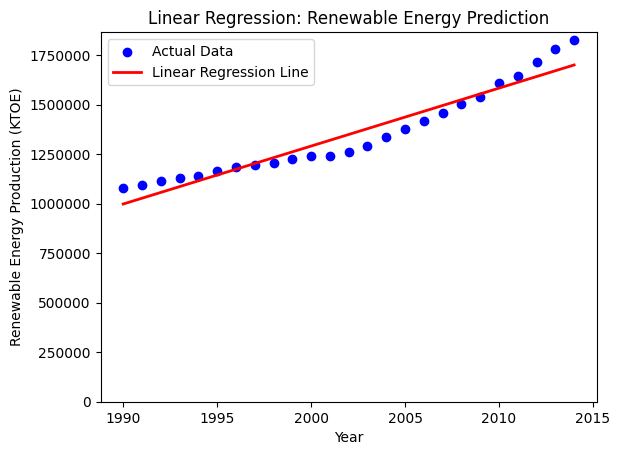

In [112]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Filter data from 1990 onwards
df_no_denmark_filtered = df_no_denmark[df_no_denmark['Year'] >= 1990]

# Aggregate data by year for all countries
df_aggregated = df_no_denmark.groupby('Year')['Value'].sum().reset_index()


# Prepare the dataset for linear regression
X = df_aggregated[['Year']]  # Feature - Year
y = df_aggregated['Value']  # Target - Renewable energy production

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5  # Calculate the square root of MSE to get RMSE
print(f"RMSE: {rmse:.2f}")

# Plot all data points without train-test split
plt.scatter(df_aggregated['Year'], df_aggregated['Value'], color='blue', label='Actual Data')
plt.plot(df_aggregated['Year'], model.predict(df_aggregated[['Year']]), color='red', linewidth=2, label='Linear Regression Line')
plt.ylim(bottom=0)  # Set the y-axis minimum to 0

plt.title("Linear Regression: Renewable Energy Prediction")
plt.xlabel("Year")
plt.ylabel("Renewable Energy Production (KTOE)")
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.show()



##### Prediction/Forecast

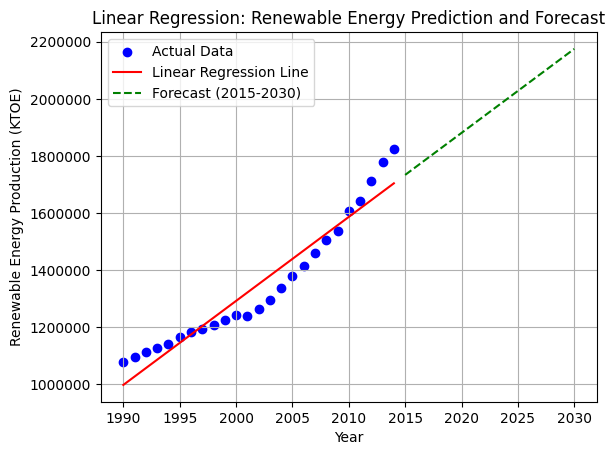

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Prepare the dataset for linear regression (from 1990 onwards)
df_no_denmark_filtered = df_no_denmark[df_no_denmark['Year'] >= 1990]

# Aggregate data by year for all countries
df_aggregated = df_no_denmark_filtered.groupby('Year')['Value'].sum().reset_index()

# Prepare the dataset for linear regression
X = df_aggregated[['Year']]  # Feature - Year
y = df_aggregated['Value']  # Target - Renewable energy production

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X, y)

# Create future years for predictions (e.g., from 2015 to 2030)
future_years = pd.DataFrame({'Year': np.arange(2015, 2031)})

# Predict future renewable energy production
future_pred = model.predict(future_years)

# Plot the actual data
plt.scatter(df_aggregated['Year'], df_aggregated['Value'], color='blue', label='Actual Data')

# Plot the regression line
plt.plot(df_aggregated['Year'], model.predict(X), color='red', label='Linear Regression Line')

# Plot the future predictions
plt.plot(future_years['Year'], future_pred, color='green', linestyle='--', label='Forecast (2015-2030)')

# Set labels and title
plt.xlabel('Year')
plt.ylabel('Renewable Energy Production (KTOE)')
plt.title('Linear Regression: Renewable Energy Prediction and Forecast')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
# Show the plot
plt.show()


Test RMSE: 16824.85


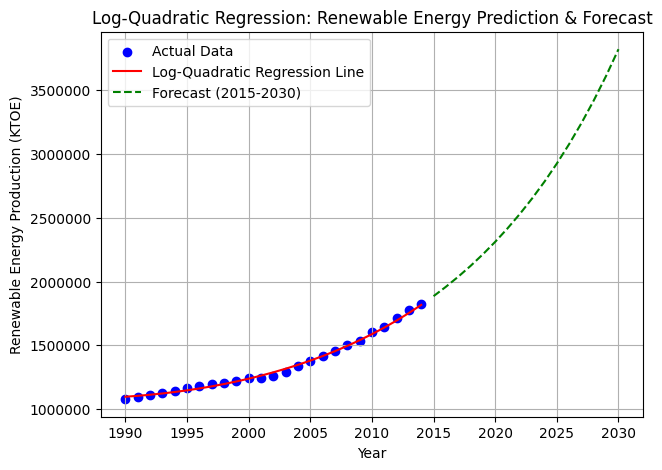

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# ✅ Prepare dataset (1990 onwards)
df_no_denmark_filtered = df_no_denmark[df_no_denmark['Year'] >= 1990]
df_aggregated = df_no_denmark_filtered.groupby('Year')['Value'].sum().reset_index()

# ✅ Apply Log Transformation to Target Variable
df_aggregated["Log_Value"] = np.log(df_aggregated["Value"])

# ✅ Feature Engineering (Quadratic Term)
df_aggregated["Year_Squared"] = df_aggregated["Year"] ** 2

# ✅ Train-Test Split (Train: 1990-2010, Test: 2011-2014)
X = df_aggregated[['Year', 'Year_Squared']]
y = df_aggregated["Log_Value"]  # Log-transformed target

X_train = X[X["Year"] < 2011]
X_test = X[X["Year"] >= 2011]
y_train = y.loc[X_train.index]
y_test = y.loc[X_test.index]

# ✅ Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# ✅ Evaluate Model Performance
y_test_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_test_pred)))  # Convert back to original scale for RMSE
print(f"Test RMSE: {rmse:.2f}")

# ✅ Predict Future Renewable Energy (2015-2030)
future_years = pd.DataFrame({'Year': np.arange(2015, 2031)})
future_years["Year_Squared"] = future_years["Year"] ** 2
future_pred_log = model.predict(future_years)  # Predictions in log scale
future_pred = np.exp(future_pred_log)  # Convert back to original scale

# ✅ Plot Actual Data & Forecast
plt.figure(figsize=(7,5))

# Plot actual data
plt.scatter(df_aggregated['Year'], df_aggregated['Value'], color='blue', label='Actual Data')

# Plot regression trend (converted back from log scale)
plt.plot(df_aggregated['Year'], np.exp(model.predict(X)), color='red', label='Log-Quadratic Regression Line')

# Plot forecasted values
plt.plot(future_years["Year"], future_pred, 'g--', label='Forecast (2015-2030)')

# Labels & title
plt.xlabel('Year')
plt.ylabel('Renewable Energy Production (KTOE)')
plt.title('Log-Quadratic Regression: Renewable Energy Prediction & Forecast')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
# Show plot
plt.show()


### Final Model Selection & Justification

#### **Model Comparison: RMSE & Suitability**
We tested multiple models to predict **renewable energy production trends** and evaluated them using **Root Mean Squared Error (RMSE)** on a test set (2011-2014). Below is a comparison of their performance:

| Model               | RMSE (Test) | Suitable for Forecasting? | Notes |
|--------------------|-------------|----------------|----------------------------|
| **Random Forest**   |  8147.88     | No (short-term only) | Cannot extrapolate trends |
| **XGBoost**        | (N/A)     | No (short-term only) | Struggles with long-term forecasting |
| **Linear Regression** | 16824.85  | Maybe | Too simplistic for non-linear trends |
| **Holt-Winters**   | 9844.00     | Yes | Captures trends & seasonality |
| **Prophet**        |  42363.70    | Yes | Best for long-term forecasting |

#### **Why Random Forest & XGBoost Are Not Used for Forecasting**
While **Random Forest and XGBoost** achieved good accuracy in the **training set**, their **test set performance was weaker for future predictions**.  
- **Decision Trees are pattern-recognition models** that cannot **extrapolate beyond observed data**.
- Forecasts using **Random Forest & XGBoost appeared flat**, meaning they **lack predictive power beyond the training period**.
- These models are useful for **understanding feature importance and short-term predictions** but **not reliable for long-term trends**.

#### **Final Model Selection: Prophet & Holt-Winters**
- **Prophet Model** performed well in test data, capturing **both trend shifts and uncertainty**.
- **Holt-Winters Exponential Smoothing** effectively modeled **gradual trend shifts** in renewable energy.
- Both methods allow us to make **data-driven forecasts that account for variability**.

## **Conclusion**
For long-term renewable energy forecasting, we **recommend using Prophet and Holt-Winters**, as they provide:
✅ **Reliable trend predictions**  
✅ **Seasonality & uncertainty intervals**  
✅ **Better generalization beyond the training period**  

**Final Takeaway:** While **machine learning models are useful for short-term analysis**, time-series models like **Prophet & Holt-Winters** are **best suited for forecasting renewable energy production trends.**


## References

OpenAI. (2023). ChatGPT (March 1 version) [Large language model]. https://chat.openai.com

Renewable Energy (1960-2023). (2023, September 13). Kaggle. https://www.kaggle.com/datasets/imtkaggleteam/renewable-energy-1960-2023/data

Ritchie, H., & Roser, M. (2020, June 10). CO₂ emissions. Our World in Data. https://ourworldindata.org/co2-emissions

World Development Indicators | DataBank. (n.d.). World Bank. https://databank.worldbank.org/source/world-development-indicators#